In [101]:
library(tidyverse)

# Read in the RDS file
final_data <- readRDS("datas_and_notebooks/final_datas/absolute_final_all_data_joined.rds")

# Display the first few rows
final_data |> 
 write.csv("datas_and_notebooks/final_datas/absolute_final_all_data_joined.csv")

In [102]:
final_data |> 
filter(plot == "bm7")# ai27 -> 2; an8 -> 4; bm7 -> 1)

date,year,site,plot,subplot,type,diversity,id,species,genus,⋯,soil_ph_k_cl,soil_n,soil_c,soil_c_n,soil_h20_all,soil_ph_k_cl_all,soil_n_all,soil_c_all,soil_c_n_all,notes
<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2024-06-09,2024,b,bm7,bm7-i,NA,1,1056,rhaphiolepis indica,rhaphiolepis,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,cunninghamia (15)
2024-06-09,2024,b,bm7,bm7-i,NA,1,65,seedling,NA,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,cunninghamia (15)
2024-06-09,2024,b,bm7,bm7-i,NA,1,94,rhaphiolepis indica,rhaphiolepis,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,cunninghamia (15)
2024-06-09,2024,b,bm7,bm7-ii,NA,1,1059,rhaphiolepis indica,rhaphiolepis,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,cunnninghamia (45)
2024-06-09,2024,b,bm7,bm7-iii,NA,1,1925,rhaphiolepis indica,rhaphiolepis,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,was 147
2024-06-09,2024,b,bm7,bm7-iii,NA,1,1733,rhus chinensis,rhus,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,was 1054
2024-06-09,2024,b,bm7,bm7-iii,NA,NA,1881,recruit,NA,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,
2024-06-09,2024,b,bm7,bm7-iv,NA,1,74,adinandra millettii,adinandra,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,cunninghamia (5)
2024-06-09,2024,b,bm7,bm7-iv,NA,1,108,loropetalum chinense,loropetalum,⋯,3.815,0.1362379,1.718452,12.39983,4.874,3.771,0.1025002,1.040096,9.85987,cunninghamia (5)


In [103]:
final_data |> 
  filter(rli > 100) |> 
  distinct(subplot)

subplot
<chr>
al10-ii
an11-i
an11-ii
an11-iv
an13-iv
aw14-i
aw14-ii
bq29-iii
bq29-iv


if number_leaves = 7 and id == 10 -> height to 10
if height is.na -> survival to "a"
external invader -> nirgends gepflanzt
internal invader -> iwo gepflanzt unterscheiden a und b
site invader
erster da, zweiter termin na, dritter da
if rli > 100 = 100
multinomiale regressionsanalyse functional group deckung 
mathematische berechunug teilbedeckung
-> auch mal integrieren nur die ersten 10 cm

In [104]:
final_data |> 
 select(percent_herb)

percent_herb
<dbl>
NA
NA
NA
NA
NA
NA
NA
NA
NA


#### Themenkomplex A: Diversität und biotischer Stress (Multitrophische Interaktionen)
Dieser Bereich testet klassische ökologische Theorien wie die *Resource Concentration Hypothesis* oder die *Enemies Hypothesis*.
* **Hauptfrage:** Verringert eine höhere Baumartenvielfalt das Ausmaß an biotischen Schäden (Herbivorie und Pilzbefall) auf individueller Pflanzenebene?
* **Spezifische Hypothesen:**
    * *H_A1:* Der prozentuale Blattschaden durch Herbivore (`percent_herb`) korreliert negativ mit der Plot-Diversität (`diversity`).
    * *H_A2:* Pilzbefall (`percent_fungal`) zeigt andere Diversitäts-Effekte als Herbivorie, da mikroklimatische Bedingungen (wie durch dichte Pflanzendecke induzierte höhere Feuchtigkeit) eine stärkere Rolle spielen als wirtsspezifische Dichte.

#### Themenkomplex B: Diversität und Produktivität (Performance & Survival)
Hier geht es um den klassischen BEF-Zusammenhang von Diversität und Produktivität, angewandt auf die Etablierungsphase.
* **Hauptfrage:** Profitieren Wachstum und Überlebensraten der Pflanzen von einer erhöhten Baumartenvielfalt (z.B. durch Nischenkomplementarität oder *Facilitation*)?
* **Spezifische Hypothesen:**
    * *H_B1:* Das Pflanzenwachstum (Zuwachs in `height` über die Zeit) ist in Plots mit höherer Diversität signifikant größer.
    * *H_B2:* Die Wahrscheinlichkeit für das Überleben (`survival`) eines Individuums steigt mit der Diversität des Plots, unabhängig von der Pflanzenspezies (`species`).

#### Themenkomplex C: Kontextabhängigkeit durch abiotische Faktoren
Oftmals überschreiben Umweltbedingungen die Diversitätseffekte oder interagieren mit ihnen (vgl. *Stress Gradient Hypothesis*).
* **Hauptfrage:** Wie modulieren abiotische Faktoren (insbesondere Licht und Bodenfeuchte) den Zusammenhang zwischen Baumartenvielfalt und Pflanzen-Performance?
* **Spezifische Hypothesen:**
    * *H_C1:* Der positive Effekt der Diversität auf das Pflanzenwachstum ist unter hohem abiotischen Stress (z.B. geringe Bodenfeuchte `soil_h20` oder extrem geringe Lichtverfügbarkeit `rli`) am stärksten ausgeprägt.
    * *H_C2:* Konkurrenz um Licht (gemessen via `rli` und `tot_veg`) ist der primäre limitierende Faktor für das Überleben, der einen möglichen positiven Diversitätseffekt maskieren kann.

#### Themenkomplex D: Taxonomische und funktionelle Identität
Nicht alle Arten reagieren gleich auf Diversität.
* **Hauptfrage:** Sind die Reaktionen auf Diversität und Umwelteinflüsse stark von der evolutionären Verwandtschaft (`family`, `genus`) oder Wuchsform (`growth_form`) abhängig?
* **Spezifische Hypothesen:**
    * *H_D1:* Bestimmte Pflanzenfamilien profitieren überproportional stark von Nachbarschafts-Diversität (z.B. aufgrund spezifischer Mykorrhiza-Assoziationen), während andere Familien neutral reagieren.

In [105]:
library(readxl)
library(janitor)
library(stringr)
library(dplyr)

site_a <- read_excel("datas_and_notebooks/metadata/plots_Site_A.xls", sheet = "Raw data") |> 
  clean_names() |> 
  mutate(across(where(is.character), ~ str_trim(tolower(.))), plot = paste0("a", plot_no))

site_b <- read_excel("datas_and_notebooks/metadata/plots_Site_B.xls", sheet = "Raw data") |> 
  clean_names() |> 
  mutate(across(where(is.character), ~ str_trim(tolower(.))), plot = paste0("b", plot_no))

In [106]:
glimpse(final_data_metadata_joined)

Rows: 4,024
Columns: 60
$ date                    <chr> "2024-05-26", "2024-05-26", "2024-05-26", "202…
$ year                    <int> 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024…
$ site                    <chr> "a", "a", "a", "a", "a", "a", "a", "a", "a", "…
$ plot                    <chr> "ac32", "ac32", "ac32", "ac32", "ac32", "ac32"…
$ subplot                 <chr> "ac32-i", "ac32-i", "ac32-i", "ac32-i", "ac32-…
$ type                    <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ diversity               <dbl> 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2…
$ id                      <chr> "276", "327", "597", "1658", "1520", "1526", "…
$ species                 <chr> "lindera reflexa", "lindera reflexa", "lindera…
$ genus                   <chr> "lindera", "lindera", "lindera", NA, "quercus"…
$ family                  <chr> "lauraceae", "lauraceae", "lauraceae", NA, "fa…
$ growth_form             <chr> "shrub/tree", "shrub/tree", "shrub/tree", NA, …
$ seed_source_sh

In [107]:
metadatasites_to_join <- site_a |> 
 full_join(site_b) |> 
 select(plot, tree_cmp, altitude, lon = x_dd, lat = y_dd)

Joining with `by = join_by(ptag, plot_no, trtm_sub, trtm_no2, tree_r, shru_r,
extinction, tree_cmp, shru_cmp, mu, vip, x_dd, y_dd, altitude, eastness,
northness, slope, solar, curv_pr, curv_pl, remarks, plot)`


In [108]:
final_data_metadata_joined <- final_data |> 
  left_join(metadatasites_to_join)  |> 
  mutate(percent_herb = number_herb_damaged/number_leaves) |> 
  mutate(
    date_parsed = ymd(date)
  ) |>
  group_by(subplot) |>
  mutate(
    time = as.numeric(difftime(date_parsed, min(date_parsed, na.rm = TRUE), units = "days"))
  ) |>
  ungroup() |>
  mutate(
    diversity = case_when(
      plot == "ai27" ~ 2,
      plot == "an8"  ~ 4,
      plot == "bm7"  ~ 1,
      TRUE ~ diversity
    )
  )

Joining with `by = join_by(plot)`
Warning message:
“There were 3 warnings in `mutate()`.
The first warning was:
ℹ In argument: `time = as.numeric(...)`.
ℹ In group 12: `subplot = "ae33.ii"`.
Caused by warning in `min.default()`:
! no non-missing arguments to min; returning Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 2 remaining warnings.”


`summarise()` has grouped output by 'subplot', 'time'. You can override using
the `.groups` argument.
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 256 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“The following aesthetics were dropped during statistical transformation:
colour.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
Warning message:
“Removed 256 rows containing missing values or values outside the scale range
(`geom_point()`).”


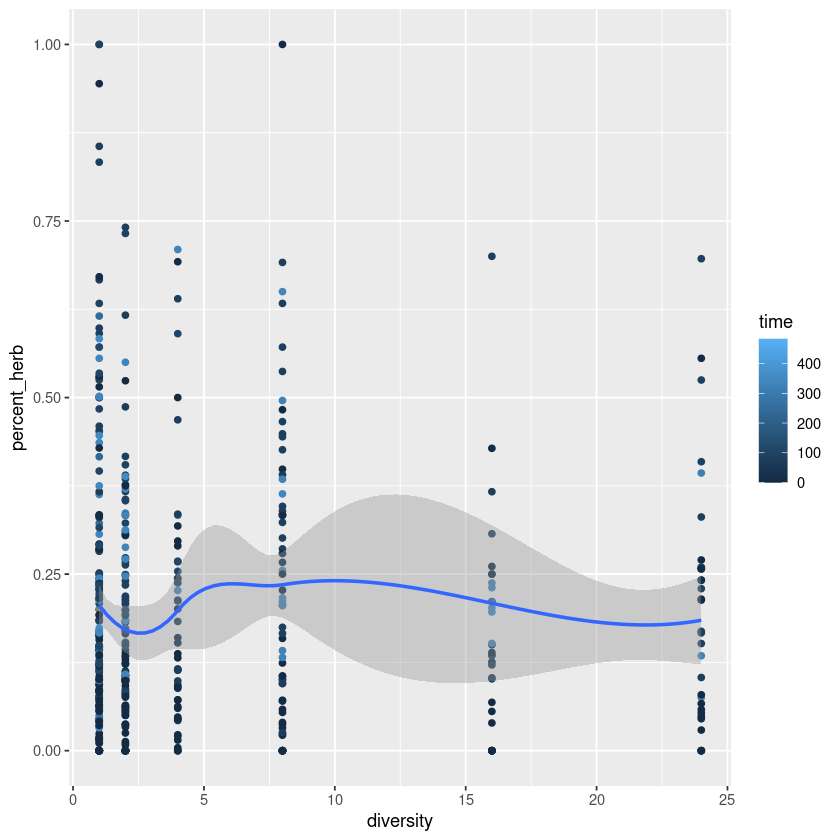

In [109]:
library(dplyr)
library(lubridate)

final_data_metadata_joined |> 
  group_by(subplot, time, diversity) |> 
  summarise(percent_herb = mean(percent_herb)) |>
  ggplot(aes(x = diversity, y = percent_herb, color = time)) + 
  geom_point() + 
  geom_smooth()

In [110]:
final_data_metadata_joined |> 
 saveRDS("datas_and_notebooks/final_datas/really_final_all_data.rds")